**Sanity Check**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
import lightgbm as lgb
import shap

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgb.__version__)
print("lightgbm:", lgb.__version__)
print("shap:", shap.__version__)

df = pd.read_csv('../data/raw/application_train.csv')
print(f"\nDataset shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.2%}")

numpy: 1.26.4
pandas: 2.2.2
sklearn: 1.5.0
xgboost: 2.0.3
lightgbm: 4.3.0
shap: 0.45.1

Dataset shape: (307511, 122)
Default rate: 8.07%


**Configuration & Display Settings**

In [2]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE = (12, 5)
RANDOM_STATE = 42

**Initial Look at Dataset**

In [3]:
print("=== Shape ===")
print(df.shape)

print("\n=== Target Distribution ===")
print(df['TARGET'].value_counts())
print(f"Default rate: {df['TARGET'].mean():.2%}")

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print("\n=== First 5 rows ===")
df.head()

=== Shape ===
(307511, 122)

=== Target Distribution ===
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate: 8.07%

=== Data Types ===
float64    65
int64      41
object     16
Name: count, dtype: int64

=== First 5 rows ===


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,...,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,...,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,-815.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
3,100006,0,Cash loans,F,N,Y,0,135000.000,312682.500,29686.500,297000.000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008,-19005,-3039,-9833.000,-2437,NaN,1,1,0,1,0,0,Laborers,2.000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,0.000,2.000,0.000,-617.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.000,513000.000,21865.500,513

**Missing Values**

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)} / {df.shape[1]}")
print(f"Columns with >50% missing:   {(missing_df.missing_pct > 50).sum()}")
print(f"Columns with >30% missing:   {(missing_df.missing_pct > 30).sum()}")

missing_df.head(20)

Columns with missing values: 67 / 122
Columns with >50% missing:   41
Columns with >30% missing:   50


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.870
COMMONAREA_AVG,214865,69.870
COMMONAREA_MODE,214865,69.870
NONLIVINGAPARTMENTS_MEDI,213514,69.430
NONLIVINGAPARTMENTS_MODE,213514,69.430
NONLIVINGAPARTMENTS_AVG,213514,69.430
FONDKAPREMONT_MODE,210295,68.390
LIVINGAPARTMENTS_MODE,210199,68.350
LIVINGAPARTMENTS_MEDI,210199,68.350
LIVINGAPARTMENTS_AVG,210199,68.350


**Target Distribution**

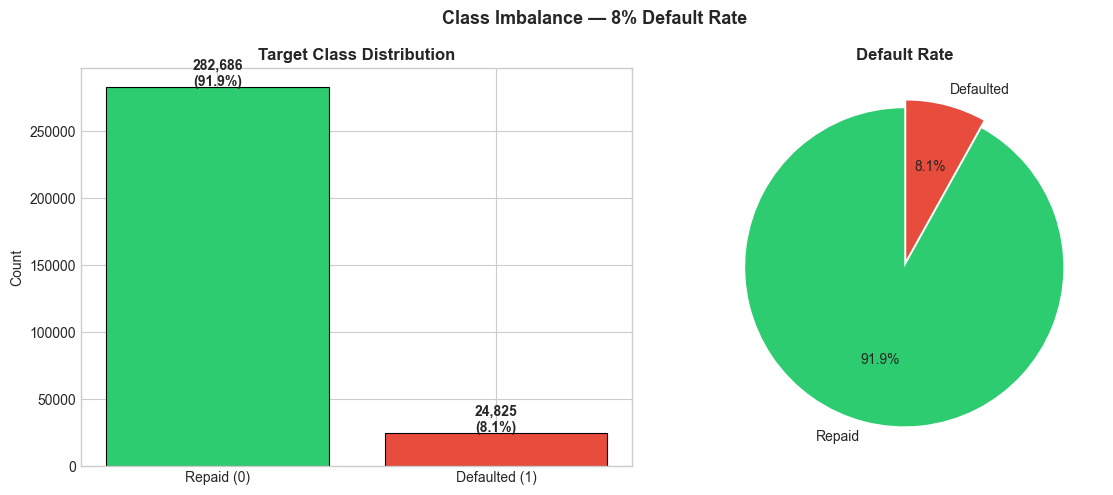

In [5]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Count plot
counts = df['TARGET'].value_counts()
axes[0].bar(['Repaid (0)', 'Defaulted (1)'], counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df):.1%})', 
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Repaid', 'Defaulted'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Default Rate', fontweight='bold')

plt.suptitle('Class Imbalance — 8% Default Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Numeric Feature Distributions**

Numeric features: 105


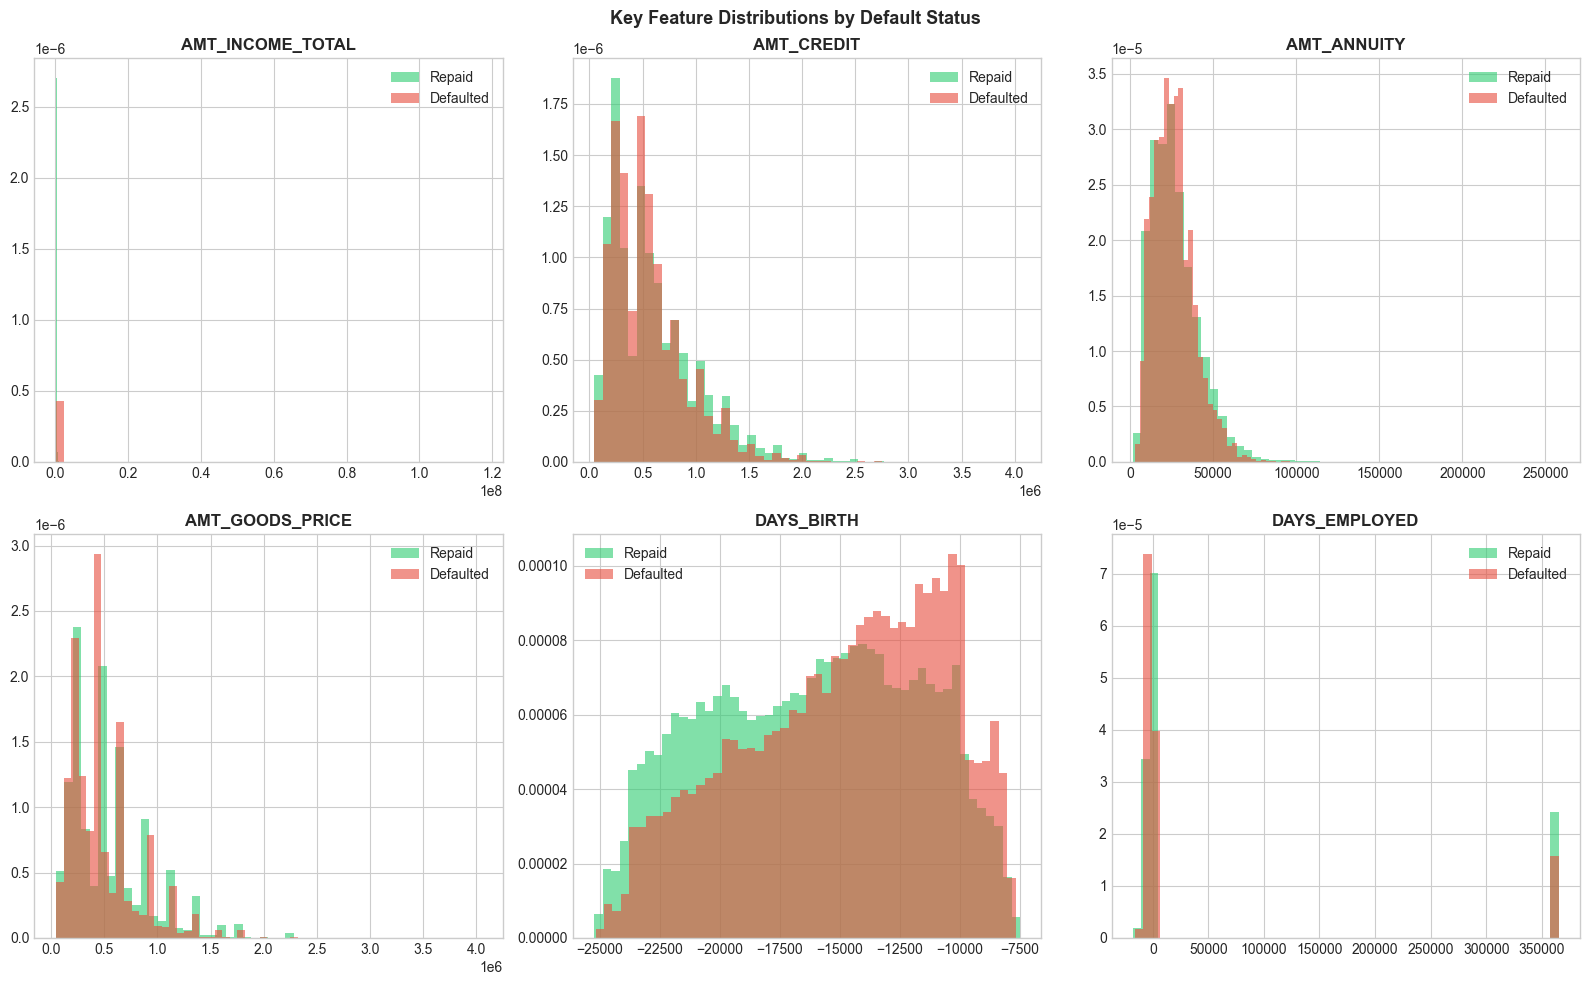

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'TARGET']

print(f"Numeric features: {len(numeric_cols)}")

# Key financial features to examine
key_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
    'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    df[df['TARGET']==0][col].dropna().hist(
        bins=50, ax=ax, alpha=0.6, color='#2ecc71', label='Repaid', density=True)
    df[df['TARGET']==1][col].dropna().hist(
        bins=50, ax=ax, alpha=0.6, color='#e74c3c', label='Defaulted', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.suptitle('Key Feature Distributions by Default Status', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Categorical Features**

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical features: {len(cat_cols)}")
print("\nUnique values per categorical column:")
print(df[cat_cols].nunique().sort_values(ascending=False))

Categorical features: 16

Unique values per categorical column:
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
CODE_GENDER                    3
HOUSETYPE_MODE                 3
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


**Default Rate by Key Categoricals**

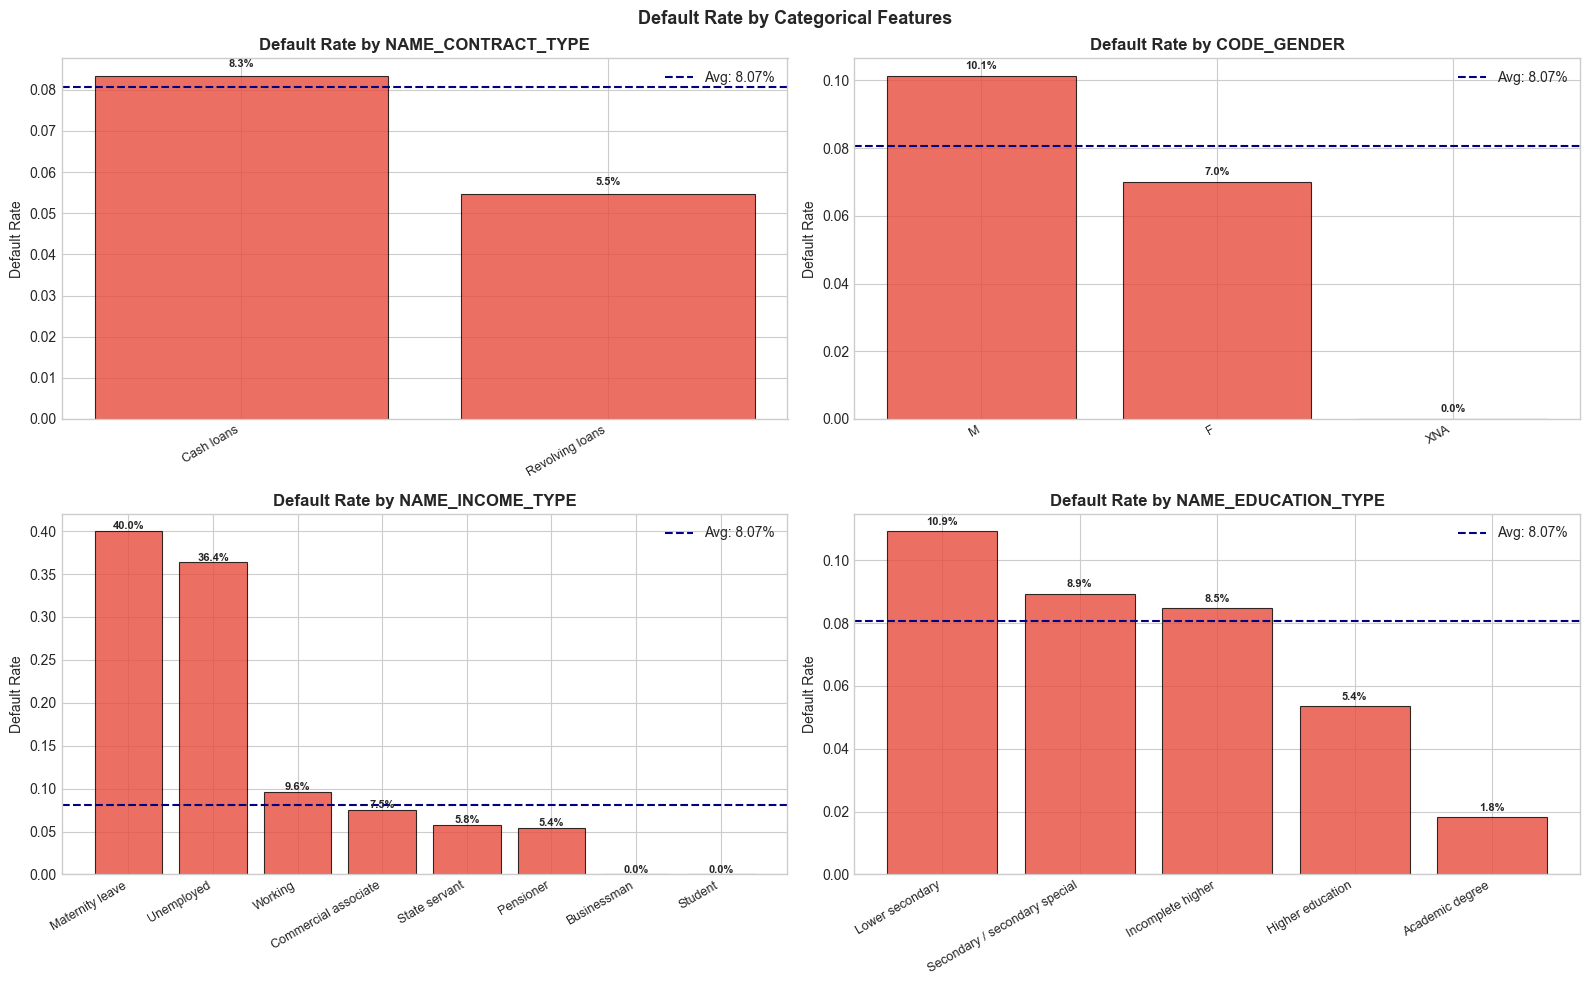

In [8]:
key_cats = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()
    
    bars = axes[i].bar(range(len(default_rate)), default_rate.values,
                       color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.8)
    axes[i].set_xticks(range(len(default_rate)))
    axes[i].set_xticklabels(default_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate')
    axes[i].axhline(df['TARGET'].mean(), color='navy', 
                    linestyle='--', linewidth=1.5, label=f'Avg: {df["TARGET"].mean():.2%}')
    axes[i].legend()
    
    for bar, val in zip(bars, default_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.1%}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Default Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()

**Correlation Heatmap**

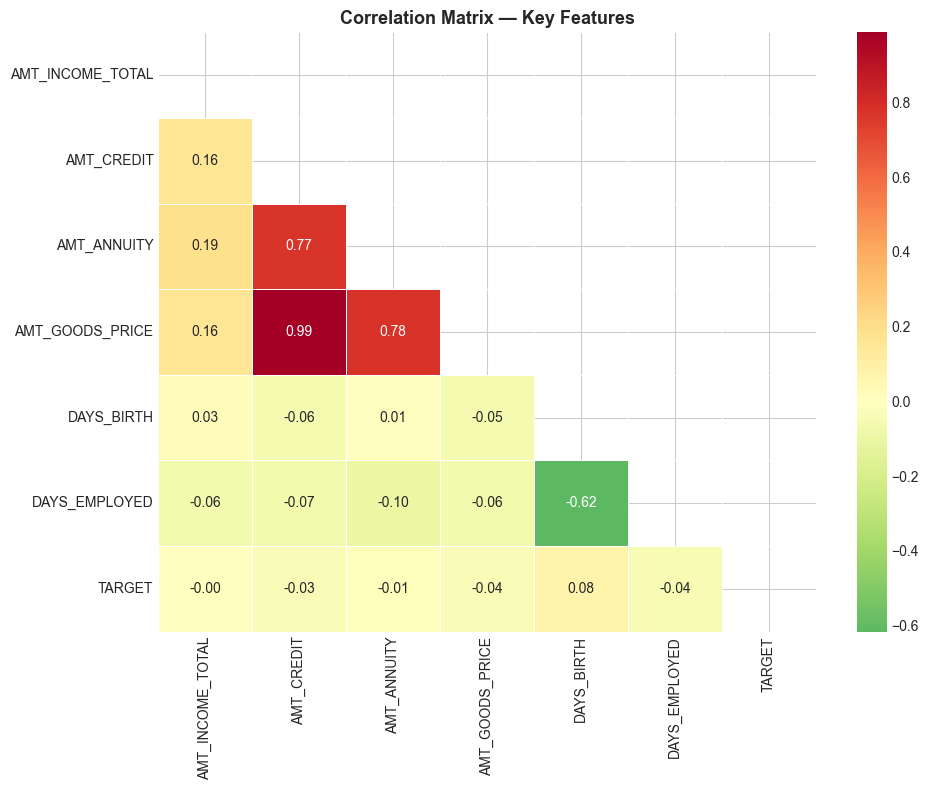

In [9]:
corr_features = key_features + ['TARGET']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Correlation Matrix — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**EDA Summary**

In [10]:
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"Total applications   : {len(df):,}")
print(f"Features             : {df.shape[1] - 1}")
print(f"Default rate         : {df['TARGET'].mean():.2%}  ← class imbalance")
print(f"Numeric features     : {len(numeric_cols)}")
print(f"Categorical features : {len(cat_cols)}")
print(f"Columns >50% missing : {(missing_df.missing_pct > 50).sum()}")
print(f"Columns >30% missing : {(missing_df.missing_pct > 30).sum()}")
print("=" * 55)
print("Next: Feature Engineering + Baseline Model")

EDA SUMMARY
Total applications   : 307,511
Features             : 121
Default rate         : 8.07%  ← class imbalance
Numeric features     : 105
Categorical features : 16
Columns >50% missing : 41
Columns >30% missing : 50
Next: Feature Engineering + Baseline Model
